In [ ]:
'!pip install pandas scikit-learn openpyxl matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import cdist

In [ ]:
# Data penjualan Toko Asri Mart
data2022_2025 = pd.read_excel('Toko Asri Mart_2022-2025.xlsx')

# Menampilkan data
print("Data Penjualan Tahun 2022-2025:")
display(data2022_2025)

Data Penjualan Tahun 2022-2025:


,Item-no,Barcode,Nama Barang,Qty,Harga Jual,Unit,Total
0,140.0,000140,MIE 3 AYAM,900,4500,PCS,4050000
1,154.0,000154,MIE AA,700,5500,PCS,3850000
2,168.0,000168,INDOMIE KARI,2200,2900,PCS,6380000
3,504.0,000504,INDOMIE GOR RENDANG,1000,2900,PCS,2900000
4,490.0,000490,INDOMIE GORENG,2800,2950,PCS,8260000
...,...,...,...,...,...,...,...
4207,1386.0,001386,STELLA MATIC W FLOWER,150,28000,PCS,4200000
4208,1387.0,001387,HIT MAT C,150,6000,PCS,900000
4209,1388.0,001388,HIT ELECTRIK,150,9000,PCS,1350000
4210,1389.0,001389,LISTERIN SAKURA PEACH,200,19000,PCS,3800000


In [ ]:
# Data Selection
data_selection = data2022_2025[['Nama Barang', 'Qty']]
print("Data Selection (Data Tahun 2022-2025):")
display(data_selection)

Data Selection (Data Tahun 2022-2025):


,Nama Barang,Qty
0,MIE 3 AYAM,900
1,MIE AA,700
2,INDOMIE KARI,2200
3,INDOMIE GOR RENDANG,1000
4,INDOMIE GORENG,2800
...,...,...
4207,STELLA MATIC W FLOWER,150
4208,HIT MAT C,150
4209,HIT ELECTRIK,150
4210,LISTERIN SAKURA PEACH,200


In [ ]:
# Memeriksa nilai null
print("Jumlah nilai yang hilang sebelum preprocessing:")

cek_null = data_selection.copy()

cek_null['Qty'] = (
    cek_null['Qty']
    .astype(str)
    .str.strip()
    .replace(['', ' ', 'NULL', 'NaN', 'nan', '-', '0'], np.nan)
)

display(cek_null.isnull().sum())


# PREPROCESSING
data_selection_cleaned = data_selection.copy()

# Membersihkan kolom Qty
data_selection_cleaned['Qty'] = (
    data_selection_cleaned['Qty']
    .astype(str)
    .str.strip()
    .replace(['', ' ', 'NULL', 'NaN', 'nan', '-', '0'], np.nan)
)

# Konversi ke numerik
data_selection_cleaned['Qty'] = pd.to_numeric(
    data_selection_cleaned['Qty'], errors='coerce'
)

# Cek jumlah null
print("\nJumlah data null di Qty sebelum dihapus:",
      data_selection_cleaned['Qty'].isnull().sum())

# Hapus data null
data_selection_cleaned = data_selection_cleaned.dropna(subset=['Qty'])

# Isi Nama Barang kosong dengan modus
if 'Nama Barang' in data_selection_cleaned.columns:
    data_selection_cleaned['Nama Barang'] = (
        data_selection_cleaned['Nama Barang']
        .fillna(data_selection_cleaned['Nama Barang'].mode()[0])
    )

# Final cleaning
data_selection_cleaned = (
    data_selection_cleaned
    .dropna()
    .reset_index(drop=True)
)

# Hasil akhir
print("\nJumlah nilai yang hilang setelah preprocessing:")
display(data_selection_cleaned.isnull().sum())

print("\nJumlah data setelah preprocessing:", len(data_selection_cleaned))

print("\nData Selection setelah penanganan missing value:")
display(data_selection_cleaned)

# Update data
data_selection = data_selection_cleaned

Jumlah nilai yang hilang sebelum preprocessing:


,0
Nama Barang,0
Qty,168



Jumlah data null di Qty sebelum dihapus: 168

Jumlah nilai yang hilang setelah preprocessing:


,0
Nama Barang,0
Qty,0



Jumlah data setelah preprocessing: 4044

Data Selection setelah penanganan missing value:


,Nama Barang,Qty
0,MIE 3 AYAM,900.0
1,MIE AA,700.0
2,INDOMIE KARI,2200.0
3,INDOMIE GOR RENDANG,1000.0
4,INDOMIE GORENG,2800.0
...,...,...
4039,STELLA MATIC W FLOWER,150.0
4040,HIT MAT C,150.0
4041,HIT ELECTRIK,150.0
4042,LISTERIN SAKURA PEACH,200.0


In [ ]:
# Agresi Data
df_selected_2022_2025 = data_selection.copy()
data_selected = {
    "2022_2025": df_selected_2022_2025,
}

for tahun, df in data_selected.items():
    print(f"Agregasi Tahun {tahun.replace('_', '-')}")

    # Kelompokkan data berdasarkan Nama Barang
    df_agg = df.groupby('Nama Barang')['Qty'].sum().reset_index()

    # Mengganti nama kolom
    df_agg.rename(columns={'Qty': f'Qty_{tahun}'}, inplace=True)

    # Simpan dataframe agregasi untuk setiap tahun ke variabel terpisah
    globals()[f'df_agg_{tahun}'] = df_agg # Ini akan membuat df_agg_2022_2025

    display(df_agg)

Agregasi Tahun 2022-2025


,Nama Barang,Qty_2022_2025
0,ABC CHO KOPI,12800.0
1,ABC KECAP ASIN,2680.0
2,ABC MILK KOPI,13400.0
3,ABC SAMBAL 175ML,3200.0
4,ABC SAMBAL 8 GR,2750.0
...,...,...
556,YAKULT,4800.0
557,YAKUT LOW,2700.0
558,YOU C1000,8200.0
559,ZINC SHAMP SACH,1520.0


In [ ]:
import pandas as pd

# Seleksi kolom numerik
print('Seleksi kolom numerik')
selected_columns = ['Qty_2022_2025']
df_selected = df_agg_2022_2025[selected_columns].copy()

display(df_selected)

Seleksi kolom numerik


,Qty_2022_2025
0,12800.0
1,2680.0
2,13400.0
3,3200.0
4,2750.0
...,...
556,4800.0
557,2700.0
558,8200.0
559,1520.0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Normalisasi data menggunakan Min-Max Scaler
scaler = MinMaxScaler()

numeric_cols_for_scaling = ['Qty_2022_2025']
df_numeric_for_scaling = df_selected.copy()

scaled = scaler.fit_transform(df_numeric_for_scaling)

# Membuat DataFrame baru dengan data yang sudah diskalakan dan nama kolom yang benar
df_scaled = pd.DataFrame(scaled, columns=numeric_cols_for_scaling)

# Tambahkan kembali kolom 'Nama Barang' dari df_agg_2022_2025
df_scaled['Nama Barang'] = df_agg_2022_2025['Nama Barang'] # Menggunakan df_agg_2022_2025 untuk mengambil 'Nama Barang'

# Mengurutkan kembali kolom
df_scaled = df_scaled[['Nama Barang', 'Qty_2022_2025']]

display(df_scaled)

,Nama Barang,Qty_2022_2025
0,ABC CHO KOPI,0.385420
1,ABC KECAP ASIN,0.077522
2,ABC MILK KOPI,0.403675
3,ABC SAMBAL 175ML,0.093343
4,ABC SAMBAL 8 GR,0.079652
...,...,...
556,YAKULT,0.142023
557,YAKUT LOW,0.078131
558,YOU C1000,0.245467
559,ZINC SHAMP SACH,0.042230


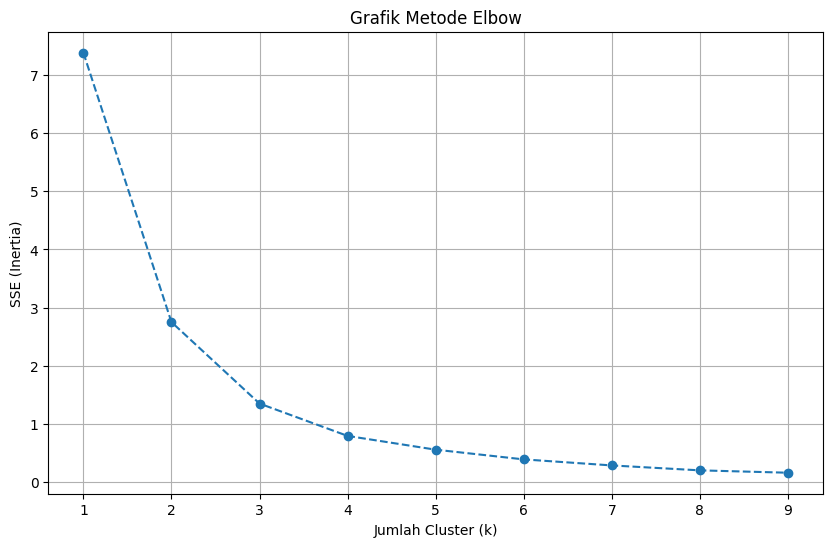

In [ ]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Ambil data untuk clustering (tanpa Nama Barang)
X = df_scaled[['Qty_2022_2025']]

# Menentukan jumlah cluster optimal
wcss = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K, wcss, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Grafik Metode Elbow')
plt.xticks(K)
plt.grid(True)
plt.show()

In [ ]:
k = 3 # Berdasarkan hasil Elbow Method, misalnya 3
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_model.fit(X)

# Menentukan centroid awal
initial_centroids = kmeans_model.cluster_centers_

print("Posisi Awal Centroid:")
for i, centroid in enumerate(initial_centroids):
    print(f"Centroid {i+1}: {centroid}")

Posisi Awal Centroid:
Centroid 1: [0.06498907]
Centroid 2: [0.57165362]
Centroid 3: [0.22495486]


In [ ]:
from scipy.spatial.distance import cdist

# Menghitung jarak data (Euclidean) ke masing-masing centroid
distances = cdist(X, kmeans_model.cluster_centers_, metric='euclidean')

# DataFrame jarak
df_distances = pd.DataFrame(distances, columns=[f'Jarak ke Centroid_{i+1}' for i in range(k)])

# Masukkan Nama Barang ke kolom pertama
df_distances.insert(0, 'Nama Barang', df_scaled['Nama Barang'])

# Menampilkan 5 baris pertama dari DataFrame jarak
print("Jarak Euclidean setiap data ke centroid:")
display(df_distances.head())

Jarak Euclidean setiap data ke centroid:


,Nama Barang,Jarak ke Centroid_1,Jarak ke Centroid_2,Jarak ke Centroid_3
0,ABC CHO KOPI,0.320431,0.186233,0.160466
1,ABC KECAP ASIN,0.012533,0.494131,0.147433
2,ABC MILK KOPI,0.338686,0.167978,0.178720
3,ABC SAMBAL 175ML,0.028354,0.478311,0.131612
4,ABC SAMBAL 8 GR,0.014663,0.492002,0.145303


DataFrame dengan penugasan Cluster dan Kategori:


,Nama Barang,Qty_2022_2025,Cluster,Category
0,ABC CHO KOPI,0.385420,2,Sedang
1,ABC KECAP ASIN,0.077522,0,Kurang Laris
2,ABC MILK KOPI,0.403675,1,Laris
3,ABC SAMBAL 175ML,0.093343,0,Kurang Laris
4,ABC SAMBAL 8 GR,0.079652,0,Kurang Laris
...,...,...,...,...
556,YAKULT,0.142023,0,Kurang Laris
557,YAKUT LOW,0.078131,0,Kurang Laris
558,YOU C1000,0.245467,2,Sedang
559,ZINC SHAMP SACH,0.042230,0,Kurang Laris


Jumlah barang di setiap cluster:


,count
Cluster,
0,445
1,18
2,98



Silhouette Score: 0.67

Rata-rata Qty per tahun untuk setiap Kategori Cluster:


,Average_Qty_2022_2025
Category,
Kurang Laris,0.064989
Laris,0.571654
Sedang,0.224955


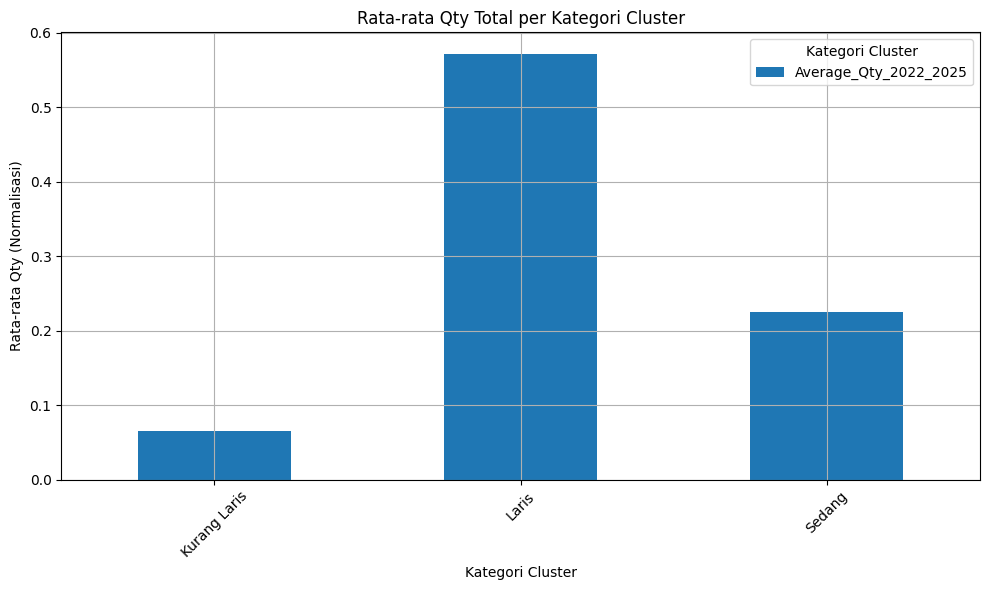

In [ ]:
# Menetapkan setiap data ke cluster terdekat
clusters = kmeans_model.predict(X)

# Menambahkan hasil cluster ke DataFrame asli (df_scaled)
df_clustered = df_scaled.copy()
df_clustered['Cluster'] = clusters

# Mendefinisikan kategori cluster berdasarkan analisis pola
cluster_categories = {
    0: 'Kurang Laris',
    1: 'Laris',
    2: 'Sedang',
}

df_clustered['Category'] = df_clustered['Cluster'].map(cluster_categories)

print("DataFrame dengan penugasan Cluster dan Kategori:")
display(df_clustered)

print("Jumlah barang di setiap cluster:")
display(df_clustered['Cluster'].value_counts().sort_index())

# Evaluasi Clustering menggunakan Silhouette Score
silhouette_avg = silhouette_score(X, clusters)
print(f"\nSilhouette Score: {silhouette_avg:.2f}")

# Analisis Pola Hasil Clustering
# Menghitung rata-rata Qty per tahun untuk setiap cluster
cluster_summary = df_clustered.groupby('Category')['Qty_2022_2025'].mean().to_frame()
cluster_summary.rename(columns={'Qty_2022_2025': 'Average_Qty_2022_2025'}, inplace=True)

print("\nRata-rata Qty per tahun untuk setiap Kategori Cluster:")
display(cluster_summary)

# Visualisasi Pola Cluster
# Karena hanya ada satu kolom Qty (Qty_2022_2025), visualisasi akan disesuaikan.
cluster_summary.plot(kind='bar', figsize=(10, 6))
plt.title('Rata-rata Qty Total per Kategori Cluster')
plt.xlabel('Kategori Cluster')
plt.ylabel('Rata-rata Qty (Normalisasi)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Kategori Cluster')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


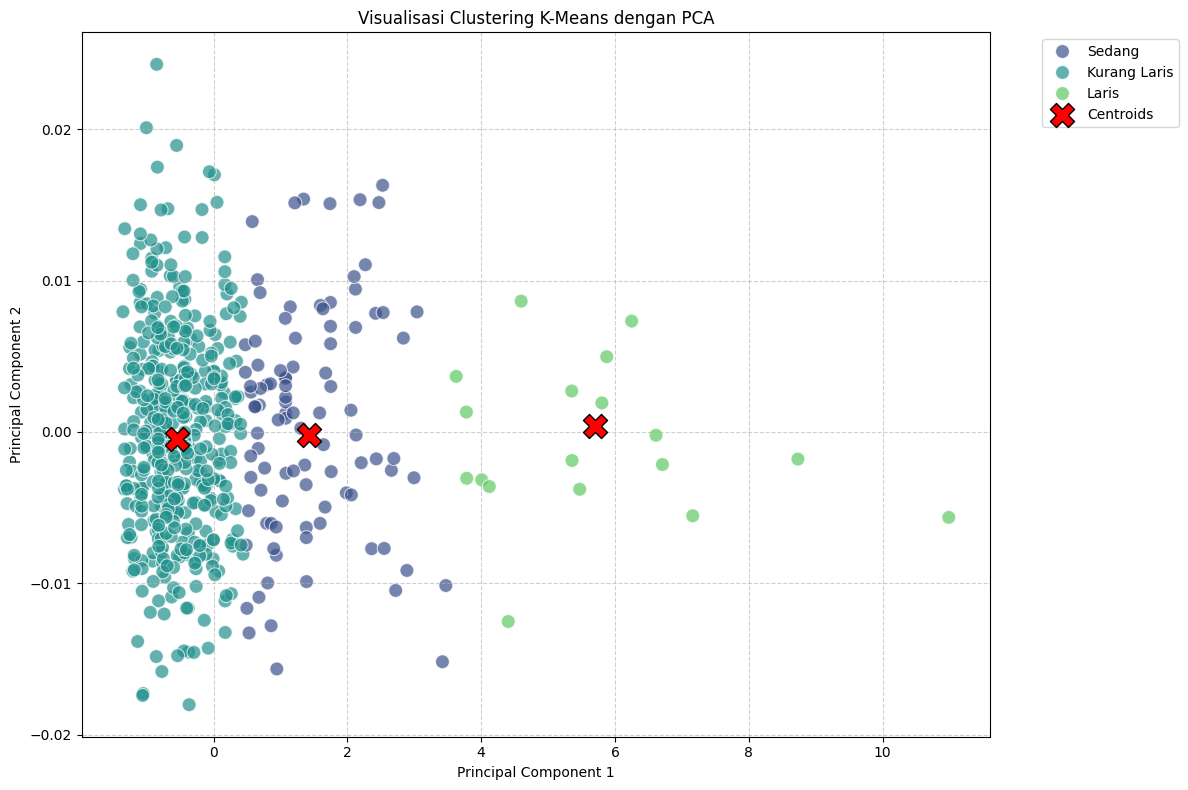

In [ ]:
# Scatter Plot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Ambil data Qty
X = df_clustered[['Qty_2022_2025']]

# 2. Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Duplikasi fitur + sedikit noise
X_fake = np.hstack([
    X_scaled,
    X_scaled + np.random.normal(0, 0.01, X_scaled.shape)
])

# 4. PCA ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_fake)

# 5. DataFrame hasil PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Category'] = df_clustered['Category']

# 6. Transform centroid ke PCA
centroids = kmeans_model.cluster_centers_

# Samakan bentuk dengan X_fake
centroids_scaled = scaler.transform(centroids)
centroids_fake = np.hstack([
    centroids_scaled,
    centroids_scaled
])

centroids_pca = pca.transform(centroids_fake)

# 7. Plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Category',
    palette='viridis',
    data=df_pca,
    s=100,
    alpha=0.7
)

# Plot centroid
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    s=300,
    marker='X',
    edgecolors='black',
    label='Centroids',
    zorder=5
)

plt.title('Visualisasi Clustering K-Means dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

10 Barang Terlaris (2022-2025):


,Nama Barang,Qty_2022_2025
196,GERY SALUUT COCO RLL 7GR,33000.0
14,AQUA CUBE,27000.0
186,GERY COKLUT EGGROLL KRIM KELAPA,22800.0
183,GERRY WAFER CREAM KELAPA TABUR,21600.0
176,GARUDA KCG KULIT 27G,21350.0
182,GERRY CHOCOLATOS ROLL,20400.0
198,GERY SN SER BANTAL,19400.0
185,GERY COKLAT TABUR PANJANG,19200.0
144,DOWNY PARFUM 20ML,18300.0
228,INDOMIE SOTO,18000.0


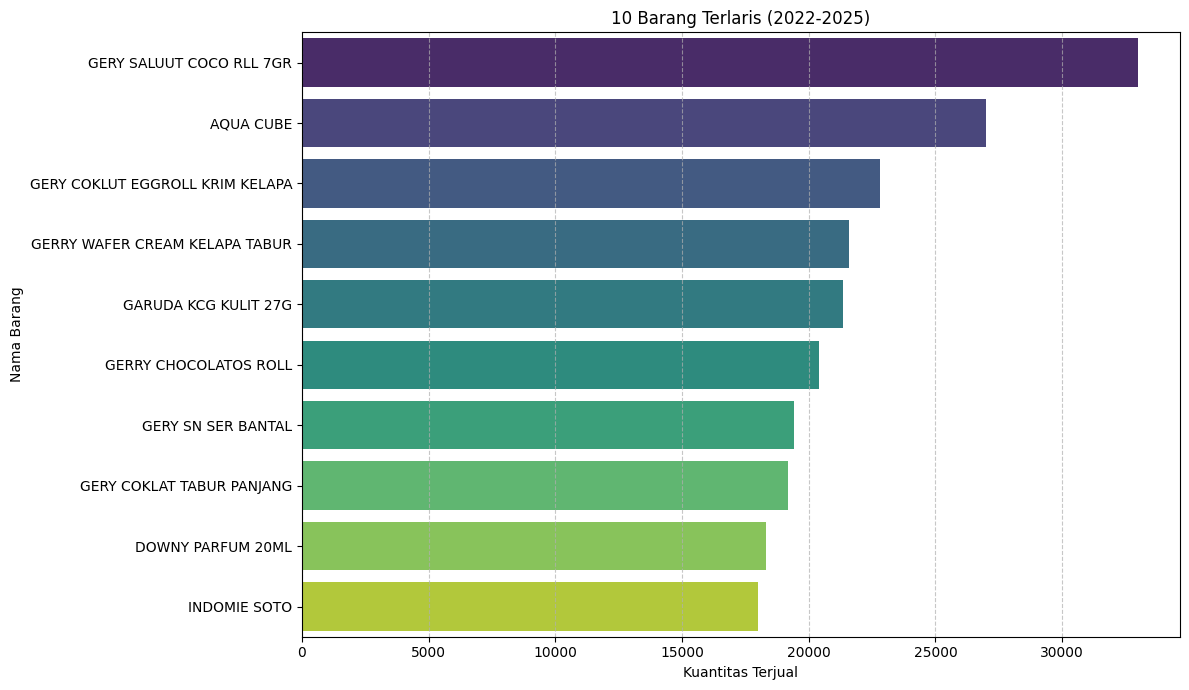

In [ ]:
# Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

print("10 Barang Terlaris (2022-2025):")
# Urutkan DataFrame berdasarkan Qty_2022_2025 secara menurun dan ambil 10 teratas
barang_terlaris = df_agg_2022_2025.sort_values(by='Qty_2022_2025', ascending=False).head(10)
display(barang_terlaris)

# Membuat diagram batang untuk 10 barang terlaris
plt.figure(figsize=(12, 7))
sns.barplot(x='Qty_2022_2025', y='Nama Barang', data=barang_terlaris, palette='viridis', hue='Nama Barang', legend=False)
plt.title('10 Barang Terlaris (2022-2025)')
plt.xlabel('Kuantitas Terjual')
plt.ylabel('Nama Barang')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()